# Өздік жұмыс: Жасырын кері байланыс (Implicit Feedback) негізінде ұсыныс жүйелерін құру

**Жұмыстың мақсаты:** Алған теориялық және практикалық білімді бекіту. Шынайы деректер базасымен жұмыс істей отырып, жасырын кері байланыс (implicit feedback) негізінде ALS (Alternating Least Squares) және SLIM (Sparse Linear Methods) алгоритмдерін өздігінен оқытып, толыққанды ұсыныс жүйесінің құбырын (pipeline) құрастыру.

## Деректерді таңдау (Datasets)

Төменде көрсетілген 5 датасеттің бірін (өз қызығушылығыңызға қарай) таңдап, жүктеп алыңыз. Содан соң төмендегі қадамдар бойынша код жазып, тапсырманы орындаңыз.

* **1. Электронды коммерция:** [Retailrocket Recommender System](https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset) (Қарау, себетке салу, сатып алу логтары)
* **2. Музыка индустриясы:**
* **3. Бөлшек сауда:** [Instacart Market Basket Analysis](https://www.google.com/search?q=https://www.kaggle.com/c/instacart-market-basket-analysis/data) (Азық-түлік себетін талдау)
* **4. Сән әлемі:** [H&M Personalized Fashion Recommendations](https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data) (Киімдерді сатып алу тарихы)
* **5. Аниме индустриясы:** [Anime Recommendations Database](https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database) (Көрген фактілерін ғана қалдырып, тазалау қажет)

## 1-қадам. Деректерді жүктеу және талдау (EDA)

**Мақсаты:** Таңдалған датасетті оқу, құрылымымен танысу. Нақты рейтингтердің орнына қолданушының әрекеттерін (сатып алу, қарау, тыңдау саны) көрсететін бағандарды анықтап, қажетсіз деректерден тазарту.

Қолданушы саны: 120
Объект саны: 180
Interaction саны: 2292
Орташа interaction / user: 19.1
view саны: 1291
cart саны: 646
purchase саны: 355


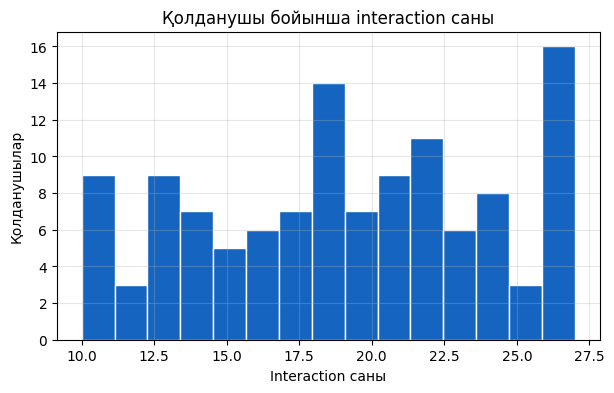

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N_USERS = 120
N_ITEMS = 180
N_CATEGORIES = 6
EVENT_WEIGHTS = {'view': 1.0, 'cart': 3.0, 'purchase': 5.0}

category_names = np.array(['Electronics', 'Books', 'Fashion', 'Food', 'Sport', 'Beauty'])
user_pref = np.random.dirichlet(np.ones(N_CATEGORIES), N_USERS)
item_category = np.random.choice(N_CATEGORIES, N_ITEMS)
item_quality = np.random.uniform(0.7, 1.3, N_ITEMS)
item_names = np.array([f"Item_{i:03d}_{category_names[item_category[i]]}" for i in range(N_ITEMS)])

interactions = []
for u in range(N_USERS):
    scores = user_pref[u, item_category] * item_quality
    scores = scores / scores.sum()
    n_seen = np.random.randint(10, 28)
    chosen_items = np.random.choice(N_ITEMS, n_seen, replace=False, p=scores)
    for item in chosen_items:
        base = user_pref[u, item_category[item]]
        event = np.random.choice(['view', 'cart', 'purchase'], p=[0.65, 0.25, 0.10])
        if base > 0.35:
            event = np.random.choice(['view', 'cart', 'purchase'], p=[0.35, 0.35, 0.30])
        interactions.append((u, item, event, EVENT_WEIGHTS[event]))

user_ids = np.array([x[0] for x in interactions])
item_ids = np.array([x[1] for x in interactions])
events = np.array([x[2] for x in interactions])
strengths = np.array([x[3] for x in interactions])

print("Қолданушы саны:", N_USERS)
print("Объект саны:", N_ITEMS)
print("Interaction саны:", len(interactions))
print("Орташа interaction / user:", round(len(interactions) / N_USERS, 2))
for event in EVENT_WEIGHTS:
    print(event, "саны:", np.sum(events == event))

plt.figure(figsize=(7, 4))
plt.hist(np.bincount(user_ids, minlength=N_USERS), bins=15, color='#1565c0', edgecolor='white')
plt.title('Қолданушы бойынша interaction саны')
plt.xlabel('Interaction саны')
plt.ylabel('Қолданушылар')
plt.grid(True, alpha=0.3)
plt.show()


## 2-қадам. Сирек матрица (Sparse Matrix) құру

**Мақсаты:** Деректерді User-Item (Қолданушы-Объект) сирек матрицасына айналдыру және сенімділік (confidence) деңгейін есептеу. Мұнда $\alpha$ (alpha) параметрін дұрыс таңдау маңызды.

User-Item matrix shape: (120, 180)
Белгілі ұяшықтар: 2292
Sparsity: 89.39%
Confidence min/max: 1.0 101.0


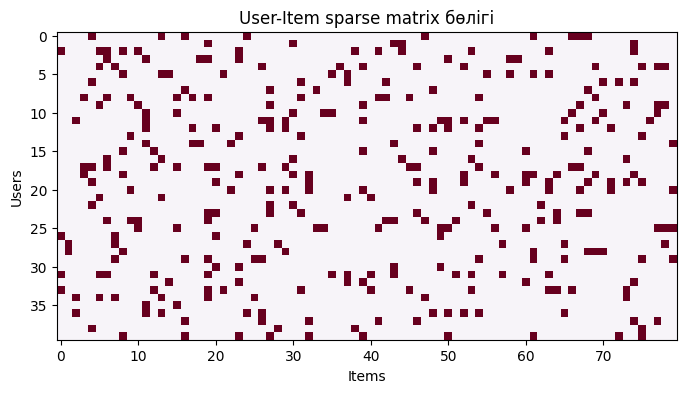

In [13]:
R = np.zeros((N_USERS, N_ITEMS), dtype=float)
for u, i, event, weight in interactions:
    R[u, i] += weight

alpha = 20
P = (R > 0).astype(float)
C = 1 + alpha * R

known = np.count_nonzero(R)
total = R.size
sparsity = 1 - known / total

print("User-Item matrix shape:", R.shape)
print("Белгілі ұяшықтар:", known)
print("Sparsity:", f"{sparsity:.2%}")
print("Confidence min/max:", C.min(), C.max())

plt.figure(figsize=(8, 4))
plt.imshow(R[:40, :80] > 0, aspect='auto', cmap='PuRd')
plt.title('User-Item sparse matrix бөлігі')
plt.xlabel('Items')
plt.ylabel('Users')
plt.show()


## 3-қадам. ALS алгоритмін оқыту

**Мақсаты:** `implicit` кітапханасын пайдаланып, ALS моделін құру. Оның гиперпараметрлерін (factors, regularization, iterations) баптап, модельді оқыту.

In [14]:
def train_als(P, C, factors=16, regularization=0.1, iterations=8):
    n_users, n_items = P.shape
    X = 0.01 * np.random.randn(n_users, factors)
    Y = 0.01 * np.random.randn(n_items, factors)
    eye = np.eye(factors)

    for epoch in range(iterations):
        for u in range(n_users):
            Cu = np.diag(C[u])
            A = Y.T @ Cu @ Y + regularization * eye
            b = Y.T @ Cu @ P[u]
            X[u] = np.linalg.solve(A, b)

        for i in range(n_items):
            Ci = np.diag(C[:, i])
            A = X.T @ Ci @ X + regularization * eye
            b = X.T @ Ci @ P[:, i]
            Y[i] = np.linalg.solve(A, b)

        scores = X @ Y.T
        loss = np.mean((P - scores) ** 2 * C)
        print(f"iteration {epoch + 1}: weighted MSE={loss:.4f}")

    return X, Y


In [15]:
als_user_factors, als_item_factors = train_als(
    P,
    C,
    factors=16,
    regularization=0.1,
    iterations=8
)

als_scores = als_user_factors @ als_item_factors.T
print("ALS оқыту аяқталды")


iteration 1: weighted MSE=0.5228
iteration 2: weighted MSE=0.2815
iteration 3: weighted MSE=0.2443
iteration 4: weighted MSE=0.2270
iteration 5: weighted MSE=0.2161
iteration 6: weighted MSE=0.2086
iteration 7: weighted MSE=0.2033
iteration 8: weighted MSE=0.1996
ALS оқыту аяқталды


In [16]:
def recommend_als(user_id, top_n=5):
    scores = als_scores[user_id].copy()
    scores[R[user_id] > 0] = -np.inf
    top_items = np.argsort(scores)[::-1][:top_n]
    return [(int(i), item_names[i], float(scores[i])) for i in top_items]

for item_id, name, score in recommend_als(0, 5):
    print(item_id, name, round(score, 4))


82 Item_082_Food 1.288
140 Item_140_Electronics 1.1853
98 Item_098_Books 1.087
37 Item_037_Electronics 1.0601
72 Item_072_Electronics 1.0128


## 4-қадам. SLIM алгоритмін оқыту

**Мақсаты:** `sklearn` кітапханасындағы `ElasticNet` моделі арқылы SLIM әдісін іске асыру. Есептеу ресурстарын үнемдеу үшін ең танымал 500 немесе 1000 объектіні ғана алып, салмақтар матрицасын (W) есептеу.

In [17]:
def train_slim(R, top_m=80, regularization=0.5):
    item_popularity = (R > 0).sum(axis=0)
    selected_items = np.argsort(item_popularity)[::-1][:top_m]
    R_small = R[:, selected_items]
    W = np.zeros((top_m, top_m))
    eye = np.eye(top_m - 1)

    for j in range(top_m):
        y = R_small[:, j]
        mask = np.arange(top_m) != j
        X = R_small[:, mask]
        A = X.T @ X + regularization * eye
        b = X.T @ y
        coef = np.linalg.solve(A, b)
        coef = np.maximum(coef, 0)
        W[mask, j] = coef

    return selected_items, W


In [18]:
slim_items, slim_W = train_slim(R, top_m=80, regularization=0.5)
R_slim = R[:, slim_items]
slim_scores_small = R_slim @ slim_W
print("SLIM оқыту аяқталды")
print("SLIM item саны:", len(slim_items))


SLIM оқыту аяқталды
SLIM item саны: 80


In [19]:
def recommend_slim(user_id, top_n=5):
    scores = slim_scores_small[user_id].copy()
    seen_small = R_slim[user_id] > 0
    scores[seen_small] = -np.inf
    top_local = np.argsort(scores)[::-1][:top_n]
    result = []
    for local_i in top_local:
        real_i = slim_items[local_i]
        result.append((int(real_i), item_names[real_i], float(scores[local_i])))
    return result

for item_id, name, score in recommend_slim(0, 5):
    print(item_id, name, round(score, 4))


49 Item_049_Food 4.1406
147 Item_147_Books 4.0883
165 Item_165_Fashion 4.0614
19 Item_019_Fashion 3.7916
48 Item_048_Books 3.5251


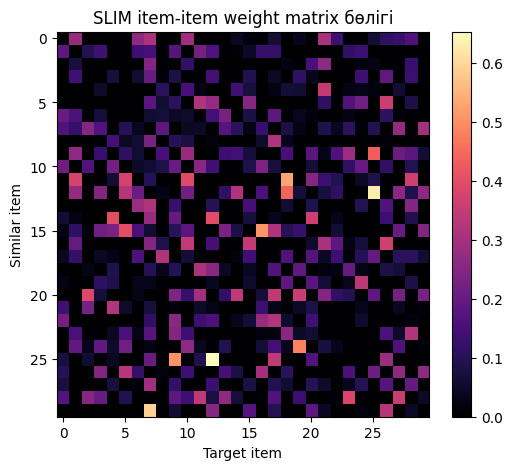

In [20]:
plt.figure(figsize=(6, 5))
plt.imshow(slim_W[:30, :30], cmap='magma', aspect='auto')
plt.title('SLIM item-item weight matrix бөлігі')
plt.xlabel('Target item')
plt.ylabel('Similar item')
plt.colorbar()
plt.show()


## 5-қадам. Нәтижені бағалау және салыстыру

**Мақсаты:** Кез келген екі қолданушыны таңдап, оларға ALS және SLIM алгоритмдері ұсынған Топ-5 объектіні (тауар, ән, фильм) экранға шығару. Модельдердің жұмысын логикалық тұрғыда бағалау.

In [21]:
test_users = [0, 7]

for u in test_users:
    seen = np.where(R[u] > 0)[0][:5]
    print("\nҚолданушы:", u)
    print("Бұрын әрекет жасаған объектілер:")
    for i in seen:
        print(" ", int(i), item_names[i], "score=", R[u, i])

    print("ALS Top-5:")
    for item_id, name, score in recommend_als(u, 5):
        print(" ", item_id, name, round(score, 4))

    print("SLIM Top-5:")
    for item_id, name, score in recommend_slim(u, 5):
        print(" ", item_id, name, round(score, 4))



Қолданушы: 0
Бұрын әрекет жасаған объектілер:
  4 Item_004_Fashion score= 1.0
  13 Item_013_Food score= 1.0
  16 Item_016_Sport score= 1.0
  24 Item_024_Food score= 3.0
  47 Item_047_Fashion score= 5.0
ALS Top-5:
  82 Item_082_Food 1.288
  140 Item_140_Electronics 1.1853
  98 Item_098_Books 1.087
  37 Item_037_Electronics 1.0601
  72 Item_072_Electronics 1.0128
SLIM Top-5:
  49 Item_049_Food 4.1406
  147 Item_147_Books 4.0883
  165 Item_165_Fashion 4.0614
  19 Item_019_Fashion 3.7916
  48 Item_048_Books 3.5251

Қолданушы: 7
Бұрын әрекет жасаған объектілер:
  16 Item_016_Sport score= 3.0
  27 Item_027_Books score= 3.0
  33 Item_033_Beauty score= 3.0
  48 Item_048_Books score= 1.0
  68 Item_068_Books score= 3.0
ALS Top-5:
  105 Item_105_Books 0.9903
  135 Item_135_Books 0.9605
  39 Item_039_Books 0.8916
  46 Item_046_Fashion 0.8755
  78 Item_078_Food 0.8322
SLIM Top-5:
  46 Item_046_Fashion 2.1063
  13 Item_013_Food 1.8617
  176 Item_176_Electronics 1.7757
  137 Item_137_Food 1.6911
  5

In [22]:
def category_match_rate(recommend_func, users, top_n=5):
    rates = []
    for u in users:
        seen_items = np.where(R[u] > 0)[0]
        if len(seen_items) == 0:
            continue
        favorite_category = np.bincount(item_category[seen_items], minlength=N_CATEGORIES).argmax()
        rec_items = [item_id for item_id, name, score in recommend_func(u, top_n)]
        rec_categories = item_category[rec_items]
        rates.append(np.mean(rec_categories == favorite_category))
    return np.mean(rates)

users_eval = np.arange(30)
als_match = category_match_rate(recommend_als, users_eval, 5)
slim_match = category_match_rate(recommend_slim, users_eval, 5)

print(f"ALS category match@5: {als_match:.3f}")
print(f"SLIM category match@5: {slim_match:.3f}")


ALS category match@5: 0.360
SLIM category match@5: 0.287


In [23]:
print("Қорытынды:")
print("ALS қолданушы мен объектіні latent factor кеңістігінде салыстырады.")
print("SLIM объектілер арасындағы item-item байланыстар арқылы ұсыныс жасайды.")
print("Implicit feedback үшін нақты рейтинг емес, әрекет күші және confidence қолданылады.")
print("Екі модель де қолданушы көрмеген объектілерді Top-N форматында ұсына алады.")


Қорытынды:
ALS қолданушы мен объектіні latent factor кеңістігінде салыстырады.
SLIM объектілер арасындағы item-item байланыстар арқылы ұсыныс жасайды.
Implicit feedback үшін нақты рейтинг емес, әрекет күші және confidence қолданылады.
Екі модель де қолданушы көрмеген объектілерді Top-N форматында ұсына алады.
